In [8]:
from google.colab import drive
import os

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Make sure ~/.kaggle exists
os.makedirs('/root/.kaggle', exist_ok=True)

# 3. Copy your token into place
!cp /content/drive/MyDrive/kaggle/kaggle.json /root/.kaggle/
!chmod 600  /root/.kaggle/kaggle.json

# 4. Install kaggle CLI (if not already)
!pip install kaggle --quiet

# 5. Test authentication
!kaggle datasets list

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sadiajavedd/students-academic-performance-dataset                  Students_Academic_Performance_Dataset                     8907  2025-10-23 04:16:35.563000           6471        162  1.0              
ayeshaimran123/social-media-and-mental-health-balance              Social Media and Mental Health Balance                    5941  2025-10-26 07:51:53.380000           6578         91  1.0              
shahzadi786/world-smartphone-market-2025                   

In [9]:
# Drive is mounted at /content/drive

target_dir = '/content/drive/MyDrive/BreakHis'
os.makedirs(target_dir, exist_ok=True)

# CLI
!kaggle datasets download -d ambarish/breakhis -p "{target_dir}" --unzip


print("Done! Files in:", target_dir)

Dataset URL: https://www.kaggle.com/datasets/ambarish/breakhis
License(s): unknown
100% 3.98G/3.99G [00:40<00:00, 123MB/s] 
100% 3.99G/3.99G [00:40<00:00, 107MB/s]
Done! Files in: /content/drive/MyDrive/BreakHis


In [ ]:
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from pathlib import Path
import pandas as pd


base_dir = Path('/content/drive/MyDrive/BreakHis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast')

records = []
for label in ['benign', 'malignant']:
    sob_dir = base_dir / label / 'SOB'
    for subtype_dir in sob_dir.iterdir():
        if not subtype_dir.is_dir():
            continue
        for slide_dir in subtype_dir.iterdir():
            if not slide_dir.is_dir():
                continue
            for mag_dir in slide_dir.iterdir():
                if not mag_dir.is_dir():
                    continue
                for img_path in mag_dir.glob('*.[pj][pn]g'):
                    records.append({
                        'path': str(img_path),
                        'label': label,
                        'subtype': subtype_dir.name,
                        'slide_id': slide_dir.name,
                        'magnification': mag_dir.name
                    })

master_df = pd.DataFrame(records)
print(f"✅ Found {len(master_df)} images")
master_df.head()

✅ Found 7909 images


,path,label,subtype,slide_id,magnification
0,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X
1,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X
2,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X
3,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X
4,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X


In [12]:
# 1. Load CSV and get expected relative paths after "breast/"

# It appears Folds.csv is located within the dataset's main folder, not directly in /content/drive/MyDrive/BreakHis
folds = pd.read_csv('/content/drive/MyDrive/BreakHis/Folds.csv')
expected = {fname.split('breast/')[1] for fname in folds['filename']}

# 2. Get actual relative paths from master_df
actual = {str(p).split('breast/')[1] for p in master_df['path']}

# 3. Compute differences
missing = expected - actual
extra   = actual   - expected

# 4. Report
print(f"Missing files: {len(missing)}")
if missing:
    for f in missing:
        print(f"  {f}")

print(f"\nExtra files: {len(extra)}")
if extra:
    for f in extra:
        print(f"  {f}")

print(f"\nTotal expected: {len(expected)}")
print(f"Total loaded:   {len(actual)}")

Missing files: 0

Extra files: 0

Total expected: 7909
Total loaded:   7909


## **Data Splitting**

In [29]:
from sklearn.model_selection import train_test_split

# Get unique slide IDs
unique_slides = master_df['slide_id'].unique()

# a) Split slides: 70% train, 15% val, 15% test
train_slides, temp_slides = train_test_split(
    unique_slides,
    test_size=0.3,
    random_state=42
)

val_slides, test_slides = train_test_split(
    temp_slides,
    test_size=0.5,  # 0.5 of 0.3 = 0.15 of total
    random_state=42
)

# b) Assign split column based on slide_id
master_df['split'] = 'train'  # Default
master_df.loc[master_df['slide_id'].isin(val_slides), 'split'] = 'val'
master_df.loc[master_df['slide_id'].isin(test_slides), 'split'] = 'test'

# c) Verify no leakage
train_slide_set = set(master_df[master_df['split']=='train']['slide_id'].unique())
val_slide_set = set(master_df[master_df['split']=='val']['slide_id'].unique())
test_slide_set = set(master_df[master_df['split']=='test']['slide_id'].unique())

print("Slide counts per split:")
print(f"Train: {len(train_slide_set)}, Val: {len(val_slide_set)}, Test: {len(test_slide_set)}")

print("\nImage counts per split:")
print(master_df['split'].value_counts())

print(f"\nSlide overlap (should be 0): {len(train_slide_set & val_slide_set & test_slide_set)}")

# d) Save updated master_df
master_df.to_csv('/content/drive/MyDrive/BreakHis/BreaKHis_v1/master_df.csv', index=False)
print("\n✅ master_df.csv updated with slide-level split!")

Slide counts per split:
Train: 57, Val: 12, Test: 13

Image counts per split:
split
train    5553
test     1351
val      1005
Name: count, dtype: int64

Slide overlap (should be 0): 0

✅ master_df.csv updated with slide-level split!


In [30]:
master_df.head()

,path,label,subtype,slide_id,magnification,split
0,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test
1,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test
2,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test
3,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test
4,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test


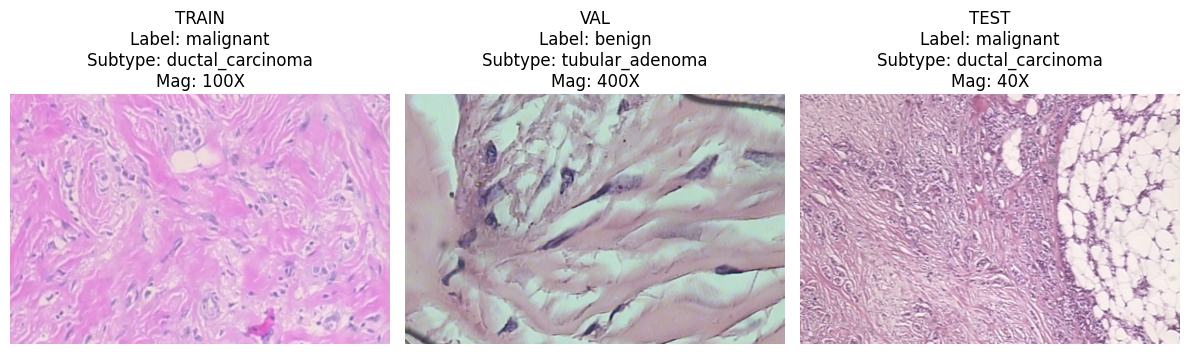

In [31]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, split in zip(axes, ['train', 'val', 'test']):
    # sample one random row from this split
    sample = master_df[master_df['split'] == split].sample(1).iloc[0]

    img = Image.open(sample['path']).convert("RGB")  # To ensure RGB format
    ax.imshow(img)

    # Title formatting
    ax.set_title(
        f"{split.upper()}\n"
        f"Label: {sample['label']}\n"
        f"Subtype: {sample['subtype']}\n"
        f"Mag: {sample['magnification']}"
    )

    ax.axis('off')

plt.tight_layout()
plt.show()

## **Exploratory Data Analysis**

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Confirm the basic structure of the DataFrame
print(master_df.shape)
master_df.head()

(7909, 6)


,path,label,subtype,slide_id,magnification,split
0,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test
1,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test
2,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test
3,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test
4,/content/drive/MyDrive/BreakHis/BreaKHis_v1/Br...,benign,adenosis,SOB_B_A_14-22549AB,100X,test


/tmp/ipython-input-1222285834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')


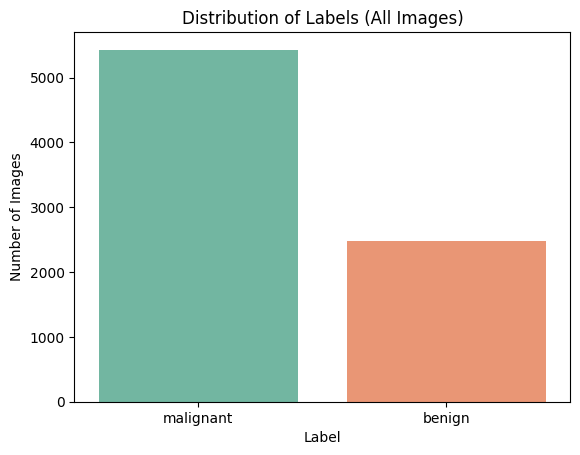

In [33]:
label_counts = master_df['label'].value_counts()

sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')
plt.title("Distribution of Labels (All Images)")
plt.xlabel("Label")
plt.ylabel("Number of Images")
plt.show()

#### Bar chart checks if the dataset is imbalanced

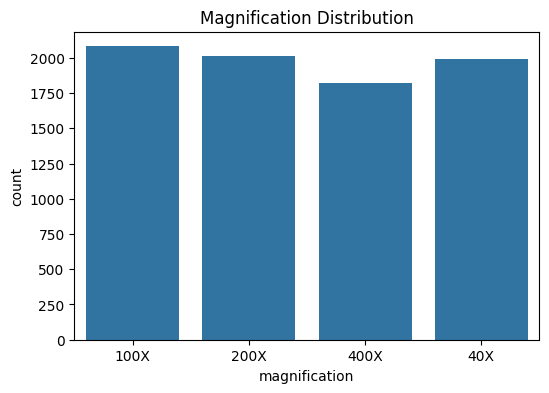

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='magnification', data=master_df)
plt.title("Magnification Distribution")
plt.show()

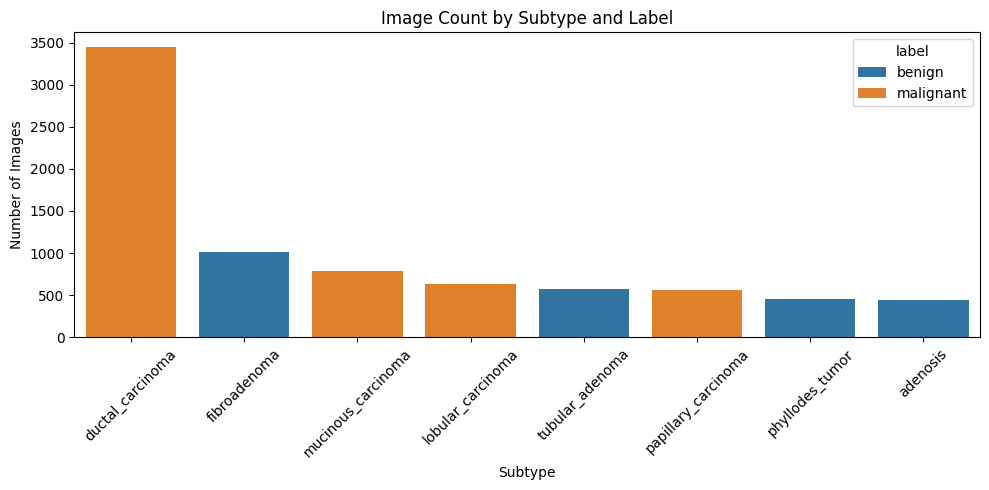

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(data=master_df, x='subtype', hue='label', order=master_df['subtype'].value_counts().index)
plt.title("Image Count by Subtype and Label")
plt.xlabel("Subtype")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

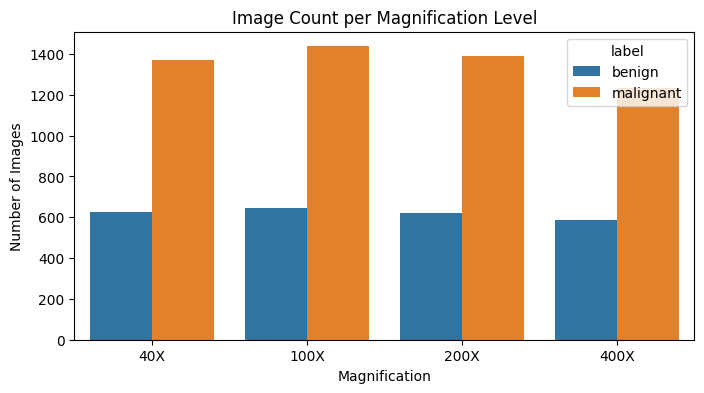

In [36]:
plt.figure(figsize=(8, 4))
sns.countplot(data=master_df, x='magnification', hue='label', order=['40X', '100X', '200X', '400X'])
plt.title("Image Count per Magnification Level")
plt.xlabel("Magnification")
plt.ylabel("Number of Images")
plt.show()

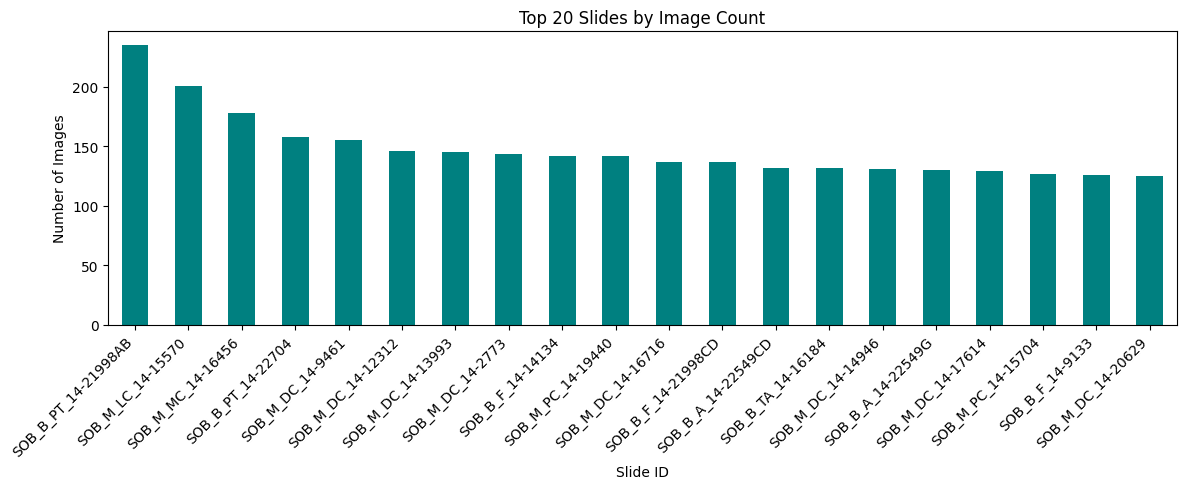

In [37]:
# Count images per slide
slide_image_counts = master_df.groupby('slide_id').size().sort_values(ascending=False)

# Plot only top 20 to avoid overcrowding
top_n = 20
slide_image_counts[:top_n].plot(kind='bar', figsize=(12, 5), color='teal')
plt.title(f"Top {top_n} Slides by Image Count")
plt.xlabel("Slide ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
# Group by slide_id and count images
slide_counts = master_df.groupby('slide_id').size().reset_index(name='image_count')

# Sort by most images
slide_counts = slide_counts.sort_values(by='image_count', ascending=False)

# Display as a list of (slide_id, image_count) tuples
slide_list = list(zip(slide_counts['slide_id'], slide_counts['image_count']))

# Print the first 10 as sample
for slide_id, count in slide_list[:10]:
    print(f"{slide_id}: {count} images")

# To view all, just print(slide_list)

SOB_B_PT_14-21998AB: 235 images
SOB_M_LC_14-15570: 201 images
SOB_M_MC_14-16456: 178 images
SOB_B_PT_14-22704: 158 images
SOB_M_DC_14-9461: 155 images
SOB_M_DC_14-12312: 146 images
SOB_M_DC_14-13993: 145 images
SOB_M_DC_14-2773: 144 images
SOB_B_F_14-14134: 142 images
SOB_M_PC_14-19440: 142 images


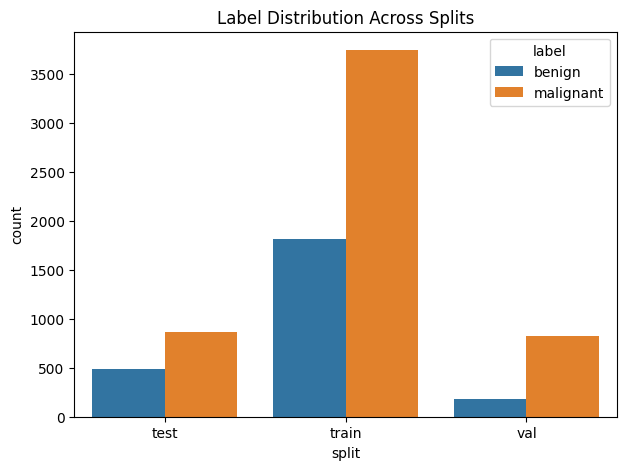

In [42]:
plt.figure(figsize=(7,5))
sns.countplot(x='split', hue='label', data=master_df)
plt.title("Label Distribution Across Splits")
plt.show()

## **Data Preparation for Model Training**

### Patches

Often, in histopathology images are very large. in other to make them usable for deep learning models (like ResNet50), I will split them into smaller, fixed-size regions called patches (e.g., 224×224 pixels).

In [44]:
# To extract 224×224 patches from each image using a sliding window.

from PIL import Image
import numpy as np

def extract_patches(img_path, patch_size=224, stride=224):
    """
    Extract non-overlapping patches from a given image.
    """
    img = Image.open(img_path).convert('RGB')
    img = np.array(img)
    h, w, _ = img.shape
    patches = []

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y+patch_size, x:x+patch_size]
            patches.append(patch)

    return patches

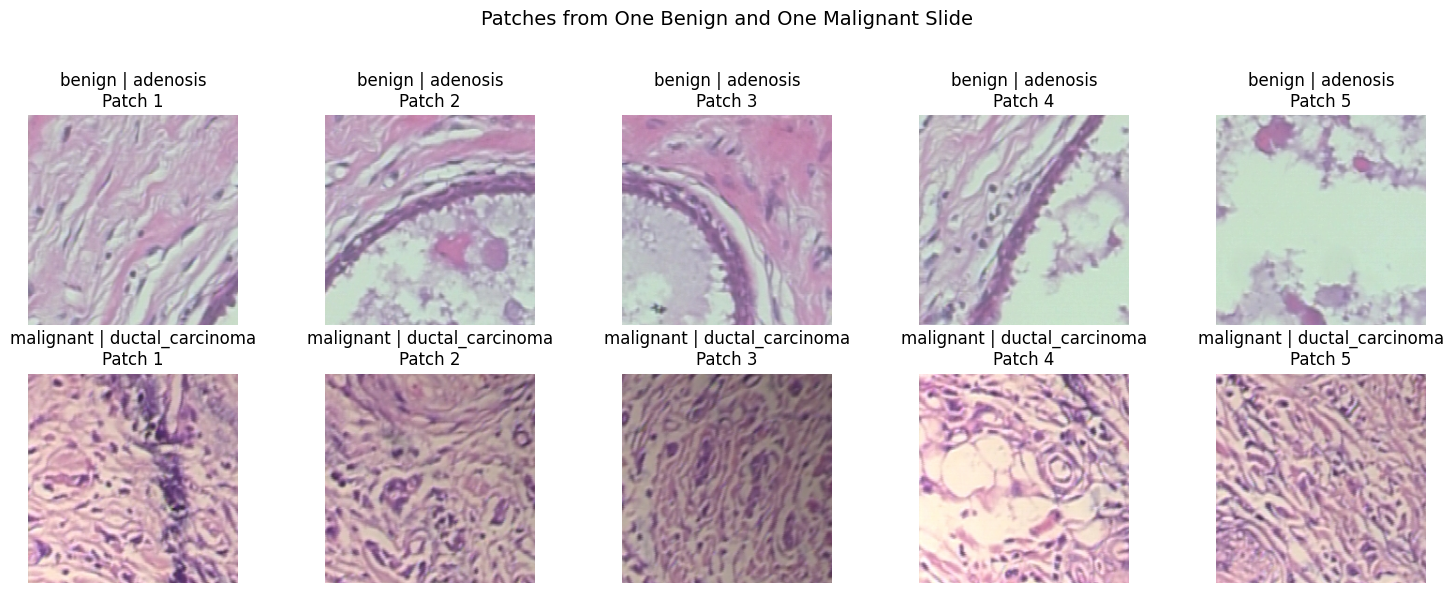

In [45]:
import matplotlib.pyplot as plt

# Select one benign and one malignant sample
benign_row = master_df[master_df['label'] == 'benign'].iloc[0]
malignant_row = master_df[master_df['label'] == 'malignant'].iloc[0]

# Get paths and metadata
samples = [
    {
        'path': benign_row['path'],
        'label': benign_row['label'],
        'subtype': benign_row['subtype']
    },
    {
        'path': malignant_row['path'],
        'label': malignant_row['label'],
        'subtype': malignant_row['subtype']
    }
]

# Plot 5 patches from each image
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row_idx, sample in enumerate(samples):
    patches = extract_patches(sample['path'])
    for i in range(5):
        ax = axes[row_idx, i]
        ax.imshow(patches[i])
        ax.set_title(f"{sample['label']} | {sample['subtype']}\nPatch {i+1}")
        ax.axis('off')

plt.suptitle("Patches from One Benign and One Malignant Slide", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [46]:
# Check the shape of the first patch
sample_patch = patches[0]
print(f"Shape of one patch: {sample_patch.shape}")

Shape of one patch: (224, 224, 3)


### Saving Patches to Disk (Organized by Split and Label)

Now saving the extracted 224×224 patches from each image to disk.

This step is important because:

It avoids re-extracting patches during training
It allows consistent and reproducible patch-level data
It separates the patch generation (preprocessing) from model training (learning)
The directory structure will look like this:

/patch_data/ ├── train/ │ ├── benign/ │ └── malignant/

├── val/ ├── test/

In [47]:
import os
import cv2
from tqdm import tqdm
from PIL import Image
import numpy as np
import pandas as pd

# Patch extractor function
def extract_patches(img_path, patch_size=224, stride=224):
    img = Image.open(img_path).convert('RGB')
    img = np.array(img)
    h, w, _ = img.shape
    patches = []

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y+patch_size, x:x+patch_size]
            patches.append(patch)

    return patches

# Save patches function
def save_patches_from_df(df, output_dir, patch_size=224):
    os.makedirs(output_dir, exist_ok=True)
    patch_records = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        slide_id = row['slide_id']
        label = row['label']
        split = row['split']
        img_path = row['path']

        try:
            patches = extract_patches(img_path, patch_size=patch_size)
        except:
            print(f"❌ Failed to extract patches from: {img_path}")
            continue

        for i, patch in enumerate(patches):
            # Directory: output_dir/split/label/
            save_dir = os.path.join(output_dir, split, label)
            os.makedirs(save_dir, exist_ok=True)

            patch_filename = f"{slide_id}_{i}.png"
            save_path = os.path.join(save_dir, patch_filename)
            cv2.imwrite(save_path, cv2.cvtColor(patch, cv2.COLOR_RGB2BGR))

            patch_records.append({
                'path': save_path,
                'label': label,
                'split': split,
                'slide_id': slide_id,
                'subtype': row['subtype'],
                'magnification': row['magnification']
            })

    return pd.DataFrame(patch_records)

# ✅ Save patches into this directory
patch_output_dir = '/content/drive/MyDrive/BreakHis/BreaKHis_v1/patches'

# Run it
patch_df = save_patches_from_df(master_df, patch_output_dir)

# Save the metadata
patch_df.to_csv(os.path.join(patch_output_dir, 'patch_df.csv'), index=False)

print("✅ All patches saved to Google Drive.")

100%|██████████| 7909/7909 [18:58<00:00,  6.95it/s]


✅ All patches saved to Google Drive.
